# Reliability plots for Szucs and Ioannidis data

In [1]:
# read csv into numpy array
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.io import loadmat

# df = pd.read_csv('../data/nudges.csv')
# list(enumerate(df.columns))

mat = loadmat('../data/psych.mat')
data = mat['D'][0,0]

raw_names = data['JournalNames'].flatten()
journal_lookup = [n.item() if hasattr(n, 'item') else n for n in raw_names]

raw_codes = data['JournalTypes']['arr'].item()
journal_codes = raw_codes.flatten().astype(int)

df = pd.DataFrame({
    'tvalues': data['tvalues'].flatten(),
    'df': data['df'].flatten()
})

# calculate 2 sided p values from t values and degrees of freedom

df['p_value'] = 2*stats.t.sf(np.abs(df['tvalues']), df['df'])

# find duplicate t-values
# type(df['tvalues'])
# duplicate_tvals = df['tvalues'][df['tvalues'].duplicated(keep=False)]

# list the unique duplicate t-values and their counts
# duplicate_tval_counts = duplicate_tvals.value_counts()
# print(duplicate_tval_counts)

# want to randomize the t-values that are rounded

Subset p-values based on 2-sided significance threshold and multiply by 20 under the null.

In [ ]:
# df['t_stat'] = df['cohens_d'] / np.sqrt(df['variance_d'])
# df['p_value']  = stats.t.cdf(-df['t_stat'], df['n_comparison'] - 2)
# df['p_value']

# subset data to only include rows where p_value < 0.05
# df = df[df['p_value'] <= 0.05]
## multiply all p values by 40
# df['p_value'] = df['p_value'] * 20
# len(df)

17207

In [2]:
import matplotlib.pyplot as plt
m = len(df)
lam = 1 - m ** (-1/5)
pi_hat_0 = np.mean(df['p_value'] > lam) / (1 - lam)
pi_hat_0

np.float64(0.2689221895601252)

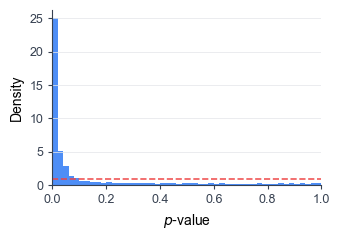

In [4]:
# Modern ML palette (same as before)
primary = "#3B82F6"   # blue
accent = "#EF4444"    # red
grid_color = "#E5E7EB"
axis_color = "#374151"

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.spines.top": False,
    "axes.spines.right": False,
})

plt.figure(figsize=(3.5, 2.5))

# Histogram (clean, no harsh black edges)
plt.hist(
    df["p_value"],
    bins=50,
    density=True,
    color=primary,
    alpha=0.9,
    edgecolor=None,
)

# Uniform reference (subtle but visible)
plt.axhline(
    1.0,
    linestyle="--",
    linewidth=1.2,
    color=accent,
    alpha=0.9,
)

plt.xlabel(r"$p$-value")
plt.ylabel("Density")

# Light horizontal grid only
plt.grid(
    True,
    axis="y",
    linestyle="-",
    linewidth=0.6,
    color=grid_color,
    alpha=0.9,
)

# Clean axis styling
ax = plt.gca()
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(axis_color)
    ax.spines[spine].set_linewidth(0.8)

ax.tick_params(axis="both", colors=axis_color, width=0.8, length=3)

plt.xlim(0, 1)

plt.tight_layout()
plt.savefig("../figures/pvalue_distribution.png", bbox_inches="tight", dpi=800)
plt.show()

## P-Value Calibration Plot

             p_bin     p_min     p_max    p_mean  count  p_bin_length  \
0  (-0.001, 0.111]  0.000000  0.111010  0.017142  19197         0.112   
1   (0.111, 0.222]  0.111133  0.222222  0.161447   1567         0.111   
2   (0.222, 0.333]  0.222347  0.333285  0.275683   1090         0.111   
3   (0.333, 0.444]  0.333812  0.444372  0.387383    927         0.111   
4   (0.444, 0.556]  0.444599  0.555244  0.498834    856         0.112   
5   (0.556, 0.667]  0.555595  0.666654  0.609377    825         0.111   
6   (0.667, 0.778]  0.666902  0.777741  0.723274    805         0.111   
7   (0.778, 0.889]  0.777819  0.888847  0.832967    749         0.111   
8     (0.889, 1.0]  0.889107  1.000000  0.944544    825         0.111   

   true_nulls_hat  proportion_true_nulls bin_start bin_end  
0      808.431735               0.042112    -0.001   0.111  
1      801.213594               0.511304     0.111   0.222  
2      801.213594               0.735058     0.222   0.333  
3      801.213594        

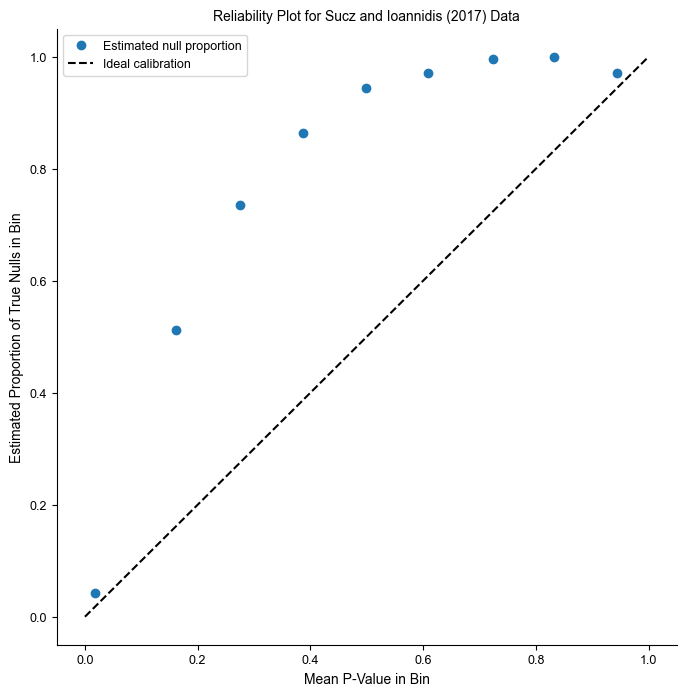

In [5]:
# p-value bins
bins = np.linspace(0, 1, 10)

# put p-values into bins
df["p_bin"] = pd.cut(df["p_value"], bins=bins, include_lowest=True, right=True)

# summarize within each p-bin
p_bin_stats = (
    df.groupby("p_bin", observed=False)
      .agg(
          p_min=("p_value", "min"),
          p_max=("p_value", "max"),
          p_mean=("p_value", "mean"),
          count=("p_value", "size")
      )
      .reset_index()
)

# total number of tests
m = len(df)

# empirical p-range length actually occupied within each bin -- actual bin length from the cuts
p_bin_stats["p_bin_length"] = p_bin_stats["p_bin"].apply(lambda x: x.right - x.left)

# expected number of nulls in that interval under Storey's estimate
p_bin_stats["true_nulls_hat"] = pi_hat_0 * m * p_bin_stats["p_bin_length"]

# estimated proportion of true nulls in each occupied bin
p_bin_stats["proportion_true_nulls"] = np.minimum(
    p_bin_stats["true_nulls_hat"] / p_bin_stats["count"],
    1.0
)

p_bin_stats["bin_start"] = p_bin_stats["p_bin"].apply(lambda x: x.left)
p_bin_stats["bin_end"] = p_bin_stats["p_bin"].apply(lambda x: x.right)

print(p_bin_stats)

# reliability plot
plt.figure(figsize=(8, 8))

plt.plot(
    p_bin_stats["p_mean"],
    p_bin_stats["proportion_true_nulls"],
    "o",
    label="Estimated null proportion"
)

plt.plot([0, 1], [0, 1], "k--", label="Ideal calibration")

plt.xlabel("Mean P-Value in Bin")
plt.ylabel("Estimated Proportion of True Nulls in Bin")
plt.title("Reliability Plot for Sucz and Ioannidis (2017) Data")

plt.legend()
plt.show()

## Q-Value Calibration Plot

In [6]:
# make q-values from p-values
def qvalues(pvals, lam=0.5):
    pvals = np.asarray(pvals)
    m = len(pvals)

    # sort p-values
    order = np.argsort(pvals)
    p_sorted = pvals[order]

    # estimate pi0
    pi0 = np.mean(pvals > lam) / (1 - lam)
    pi0 = min(pi0, 1.0)

    # compute initial q-values (i.e. pFDRs for each p-value)
    qvals = pi0 * m * p_sorted / np.arange(1, m + 1)

    # enforce monotonicity by taking minimum at each step
    qvals = np.minimum.accumulate(qvals[::-1])[::-1]
    qvals = np.minimum(qvals, 1.0)

    # return in original order
    q_original = np.empty_like(qvals)
    q_original[order] = qvals

    return q_original

df['q_value'] = qvalues(df['p_value'])


               q_bin     p_min     p_max    p_mean    q_mean  count  \
0   (-0.001, 0.0256]  0.000000  0.063288  0.012242  0.006187  17879   
1   (0.0256, 0.0513]  0.063335  0.139439  0.094883  0.036369   1818   
2   (0.0513, 0.0769]  0.139557  0.220242  0.177800  0.063568   1045   
3    (0.0769, 0.103]  0.220404  0.305915  0.261521  0.089356    864   
4     (0.103, 0.128]  0.306134  0.396226  0.349585  0.115009    784   
5     (0.128, 0.154]  0.396419  0.491990  0.444058  0.141120    771   
6     (0.154, 0.179]  0.492382  0.593183  0.543042  0.166926    775   
7     (0.179, 0.205]  0.593320  0.699625  0.646405  0.192411    768   
8     (0.205, 0.231]  0.699810  0.813200  0.757698  0.218416    820   
9     (0.231, 0.256]  0.813378  0.933336  0.876465  0.244589    837   
10    (0.256, 0.282]  0.933783  1.000000  0.968700  0.263637    480   
11    (0.282, 0.308]       NaN       NaN       NaN       NaN      0   
12    (0.308, 0.333]       NaN       NaN       NaN       NaN      0   
13    

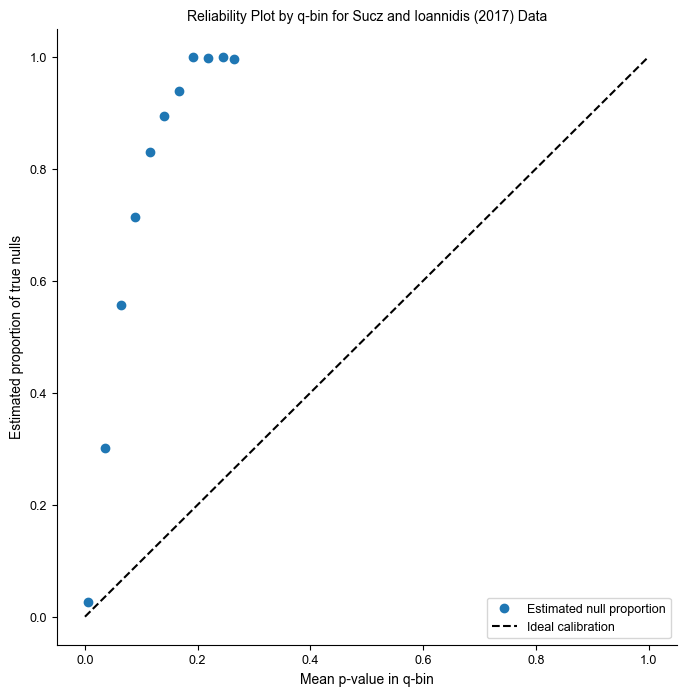

In [7]:
# q-value bins
bins = np.linspace(0, 1, 40)

# put q-values into bins
df["q_bin"] = pd.cut(df["q_value"], bins=bins, include_lowest=True, right=True)

# summarize p-values within each q-bin
q_bin_stats = (
    df.groupby("q_bin", observed=False)
      .agg(
          p_min=("p_value", "min"),
          p_max=("p_value", "max"),
          p_mean=("p_value", "mean"),
          q_mean=("q_value", "mean"),
          count=("p_value", "size")
      )
      .reset_index()
)

# empirical p-range length induced by each q-bin
q_bin_stats["p_bin_length"] = q_bin_stats["p_max"] - q_bin_stats["p_min"]

# expected number of nulls in that p-interval under Storey's estimate
q_bin_stats["true_nulls_hat"] = pi_hat_0 * m * q_bin_stats["p_bin_length"]

# estimated null proportion within the q-bin
q_bin_stats["proportion_true_nulls"] = np.minimum(
    q_bin_stats["true_nulls_hat"] / q_bin_stats["count"],
    1.0
)

# optional: q-bin endpoints for reference
q_bin_stats["q_bin_start"] = q_bin_stats["q_bin"].apply(lambda x: x.left)
q_bin_stats["q_bin_end"] = q_bin_stats["q_bin"].apply(lambda x: x.right)

print(q_bin_stats)

plt.figure(figsize=(8, 8))

plt.plot(q_bin_stats["q_mean"], q_bin_stats["proportion_true_nulls"], "o", label="Estimated null proportion")

# # add vertical dashed red lines at p_min and p_max
# for _, row in q_bin_stats.iterrows():
#     plt.axvline(row["p_min"], color="red", linestyle="--", alpha=0.4)
#     plt.axvline(row["p_max"], color="red", linestyle="--", alpha=0.4)

# 45-degree reference line
plt.plot([0, 1], [0, 1], "k--", label="Ideal calibration")

plt.xlabel("Mean p-value in q-bin")
plt.ylabel("Estimated proportion of true nulls")
plt.title("Reliability Plot by q-bin for Sucz and Ioannidis (2017) Data")

plt.legend()
plt.show()

## lfdr Calibration Plot

In [8]:
%reload_ext autoreload
%autoreload 2
from npeb import Grenander, local_fdr

(CVXPY) May 20 05:49:42 PM: Encountered unexpected exception importing solver MOSEK:
ImportError("cannot import name '_msk' from partially initialized module 'mosek' (most likely due to a circular import) (/Users/adway/src/research-code/calibration-multiple-testing/.venv/lib/python3.14/site-packages/mosek/__init__.py)")


In [15]:
# check and see if there are duplicates in the p-values
print(f"Number of unique p-values: {len(df['p_value'].unique())}")
print(f"Total number of p-values: {len(df['p_value'])}")

duplicate_pvals = df['p_value'][df['p_value'].duplicated(keep=False)]

# list the unique duplicate p-values and their counts
duplicate_pval_counts = duplicate_pvals.value_counts()
print(duplicate_pval_counts)

# keep only the unique p-values for Grenander fitting
unique_pvals = df['p_value'].unique()
unique_pvals.sort()
unique_pvals
# remove any p-values that are exactly 0 or 1
# unique_pvals = unique_pvals[(unique_pvals > 0) & (unique_pvals < 1)]

# find minimum gap between unique p-values
pval_gaps = np.diff(unique_pvals)
min_gap = np.min(pval_gaps)
print(f"Minimum gap between unique p-values: {min_gap}")

max_gap = np.max(pval_gaps)
print(f"Maximum gap between unique p-values: {max_gap}")

# split the p-values into a training and testing set
# random index for training set
train_idx = np.random.choice(len(unique_pvals), size=int(0.5 * len(unique_pvals)), replace=False)
train_pvals = unique_pvals[train_idx]
test_pvals = unique_pvals[~np.isin(unique_pvals, train_pvals)]

Number of unique p-values: 20393
Total number of p-values: 26841
p_value
1.000000    41
0.043896    16
0.036224    13
0.037350    12
0.016459    12
            ..
0.442300     2
0.269130     2
0.003979     2
0.272229     2
0.000414     2
Name: count, Length: 4018, dtype: int64
Minimum gap between unique p-values: 1.1328954151759087e-273
Maximum gap between unique p-values: 0.0019575658449457745


In [16]:
# fit grenander to the unique p-values
gren = Grenander(x_min=-0.1, x_max=1.1)
fhat_split =  gren.fit(train_pvals)
# fhat = gren.fit(unique_pvals)

In [17]:
pi_hat_0_gren = np.mean(test_pvals > 0.5) / (1 - 0.5)
test_lfdr = np.minimum(pi_hat_0_gren / gren.pdf(test_pvals), 1)
test_df = pd.DataFrame({
    'p_value': test_pvals,
    'lfdr': test_lfdr
})

/var/folders/2p/pvl5m11d621fk0xffszjtbw80000gn/T/ipykernel_17893/367495689.py:2: RuntimeWarning: divide by zero encountered in divide
  test_lfdr = np.minimum(pi_hat_0_gren / gren.pdf(test_pvals), 1)


          lfdr_bin     p_min     p_max    p_mean  lfdr_mean  count  \
0  (-0.001, 0.111]  0.000000  0.051265  0.008795   0.061079   6611   
1   (0.111, 0.222]  0.051306  0.080801  0.064274   0.186131    419   
2   (0.222, 0.333]  0.081009  0.103653  0.090842   0.272213    214   
3   (0.333, 0.444]  0.103717  0.150495  0.125567   0.393385    289   
4   (0.444, 0.556]  0.150672  0.183950  0.166384   0.510738    180   
5   (0.556, 0.667]  0.184488  0.233849  0.209294   0.603002    217   
6   (0.667, 0.778]  0.234383  0.348443  0.289105   0.716404    446   
7   (0.778, 0.889]  0.349114  0.372350  0.362093   0.872631     76   
8     (0.889, 1.0]  0.373020  1.000000  0.671890   0.968483   1745   

   p_bin_length  true_nulls_hat  proportion_true_nulls lfdr_bin_start  \
0      0.051265      137.391250               0.020782         -0.001   
1      0.029495       79.045598               0.188653          0.111   
2      0.022644       60.686873               0.283584          0.222   
3      

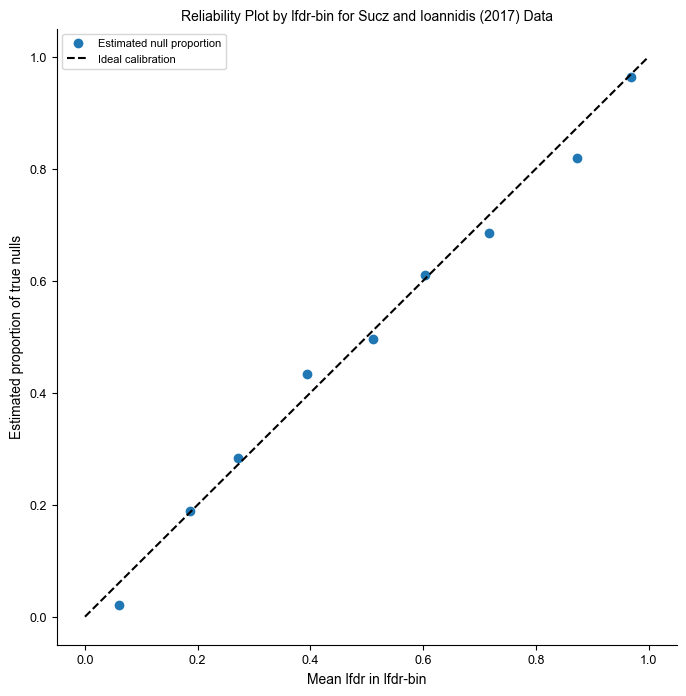

In [18]:
# lfdr bins
bins = np.linspace(0, 1, 10)

# put lfdr  into bins
# df["lfdr_bin"] = pd.cut(df["lfdr"], bins=bins, include_lowest=True, right=True)
test_df["lfdr_bin"] = pd.cut(test_df["lfdr"], bins=bins, include_lowest=True, right=True)

# m = len(df)
m = len(test_df)

# summarize p-values within each lfdr-bin
lfdr_bin_stats = (
    test_df.groupby("lfdr_bin", observed=False)
      .agg(
          p_min=("p_value", "min"),
          p_max=("p_value", "max"),
          p_mean=("p_value", "mean"),
          lfdr_mean=("lfdr", "mean"),
          count=("p_value", "size")
      )
      .reset_index()
)

# empirical p-range length induced by each lfdr-bin
lfdr_bin_stats["p_bin_length"] = lfdr_bin_stats["p_max"] - lfdr_bin_stats["p_min"]

# expected number of nulls in that p-interval under Storey's estimate
lfdr_bin_stats["true_nulls_hat"] = pi_hat_0_gren * m * lfdr_bin_stats["p_bin_length"]

# estimated null proportion within the lfdr-bin
lfdr_bin_stats["proportion_true_nulls"] = np.minimum(
    lfdr_bin_stats["true_nulls_hat"] / lfdr_bin_stats["count"],
    1.0
)

lfdr_bin_stats["lfdr_bin_start"] = lfdr_bin_stats["lfdr_bin"].apply(lambda x: x.left)
lfdr_bin_stats["lfdr_bin_end"] = lfdr_bin_stats["lfdr_bin"].apply(lambda x: x.right)

print(lfdr_bin_stats)

# plot reliability plot for lfdr bins (estimated null proportion vs. mean lfdr in bin)

plt.figure(figsize=(8, 8))

plt.plot(lfdr_bin_stats["lfdr_mean"], lfdr_bin_stats["proportion_true_nulls"], "o", label="Estimated null proportion")

plt.plot([0, 1], [0, 1], "k--", label="Ideal calibration")

plt.xlabel("Mean lfdr in lfdr-bin")
plt.ylabel("Estimated proportion of true nulls")
plt.title("Reliability Plot by lfdr-bin for Sucz and Ioannidis (2017) Data")

plt.legend()
plt.show()

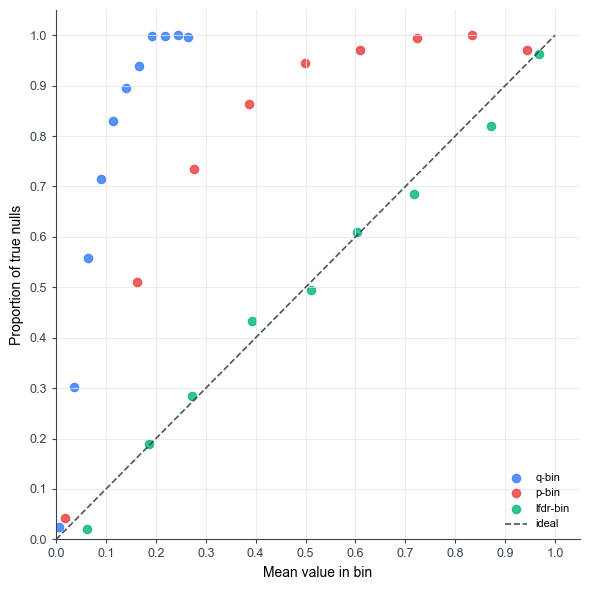

In [19]:
# Color scheme (from your histogram)
primary = "#3B82F6"   # blue
accent = "#EF4444"    # red
green = "#10B981"     # add a third distinct color
grid_color = "#E5E7EB"
axis_color = "#374151"
dot_size = 35

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.spines.top": False,
    "axes.spines.right": False,
})

plt.figure(figsize=(6, 6))

# --- Scatter plots with distinct styles ---
plt.scatter(
    q_bin_stats["q_mean"],
    q_bin_stats["proportion_true_nulls"],
    s=dot_size,
    color=primary,
    alpha=0.85,
    label="q-bin",
)

plt.scatter(
    p_bin_stats["p_mean"],
    p_bin_stats["proportion_true_nulls"],
    s=dot_size,
    color=accent,
    alpha=0.85,
    label="p-bin",
)

plt.scatter(
    lfdr_bin_stats["lfdr_mean"],
    lfdr_bin_stats["proportion_true_nulls"],
    s=dot_size,
    color=green,
    alpha=0.85,
    label="lfdr-bin",
)

# --- Ideal calibration line ---
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.2,
    color=axis_color,
    alpha=0.9,
    label="ideal",
)

# --- Axes ---
plt.xlabel("Mean value in bin")
plt.ylabel("Proportion of true nulls")

plt.xlim(0, 1.05)
plt.ylim(0, 1.05)

# --- Gridlines at 0.1 increments ---
ticks = np.arange(0, 1.05, 0.1)
plt.xticks(ticks)
plt.yticks(ticks)

plt.grid(
    True,
    which="major",
    linestyle="-",
    linewidth=0.6,
    color=grid_color,
    alpha=0.9,
)

# --- Axis styling ---
ax = plt.gca()
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(axis_color)
    ax.spines[spine].set_linewidth(0.8)

ax.tick_params(axis="both", colors=axis_color, width=0.8, length=3)

# --- Legend ---
plt.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.savefig("../figures/ioannidis_reliability_plot.png", bbox_inches="tight", dpi=800)
plt.show()

## Blasiok Smooth ECE

In [20]:
# create stochastically supervised labels 
# calculate gaps between sorted p-values
sorted_pvals = np.sort(test_pvals)
# concat zero at the beginning and one at the end to capture edge gaps
sorted_pvals = np.concatenate(([0], sorted_pvals))
pval_gaps = np.diff(sorted_pvals)
y_tilde = len(test_pvals) * pi_hat_0_gren * pval_gaps

# sort test lfdrs in the same order as the sorted p-values
sorted_lfdr = test_lfdr[np.argsort(test_pvals)]

def reflected_gaussian_weights(f, f_train, sigma, K=5):
    f_train = np.asarray(f_train)
    weights = np.zeros_like(f_train, dtype=float)

    for k in range(-K, K + 1):
        weights += np.exp(-0.5 * ((f - f_train - 2*k) / sigma)**2)
        weights += np.exp(-0.5 * ((f + f_train - 2*k) / sigma)**2)

    return weights

def mu_hat(f_eval, f_train, y_train, sigma, K=5):
    f_eval = np.asarray(f_eval)[:, None]      # shape (m, 1)
    f_train = np.asarray(f_train)[None, :]    # shape (1, n)
    y_train = np.asarray(y_train)

    weights = np.zeros((f_eval.shape[0], f_train.shape[1]))

    for k in range(-K, K + 1):
        weights += np.exp(-0.5 * ((f_eval - f_train - 2*k) / sigma)**2)
        weights += np.exp(-0.5 * ((f_eval + f_train - 2*k) / sigma)**2)

    # normalize row-wise
    weights_sum = weights.sum(axis=1, keepdims=True)

    return (weights @ y_train) / weights_sum.squeeze()

In [21]:
local_null_prop_lfdr = mu_hat(sorted_lfdr, sorted_lfdr, y_tilde, sigma=0.1)

In [20]:
q_vals = qvalues(np.sort(test_pvals))
len(test_pvals), len(y_tilde), len(q_vals)

local_null_prop_q = mu_hat(q_vals, q_vals, y_tilde, sigma=0.1)

In [21]:
p_vals = np.sort(test_pvals)
local_null_prop_p = mu_hat(p_vals, p_vals, y_tilde, sigma=0.1)

In [22]:
# save the local null proportion estimates and the corresponding sorted p-values, q-values, and lfdrs into a pckl file
import pickle

with open("../data/smooth_ece_estimates.pkl", "wb") as f:
    pickle.dump({
        "sorted_lfdr": sorted_lfdr,
        "q_vals": q_vals,
        "p_vals": p_vals,
        "local_null_prop_lfdr": local_null_prop_lfdr,
        "local_null_prop_q": local_null_prop_q,
        "local_null_prop_p": local_null_prop_p
    }, f)

/var/folders/2p/pvl5m11d621fk0xffszjtbw80000gn/T/ipykernel_1437/3324371295.py:7: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], "k--", label="ideal", color=axis_color, alpha=0.9)


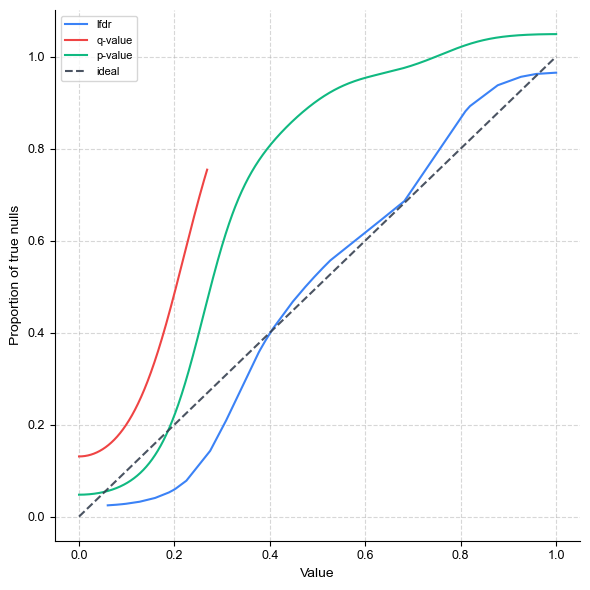

In [23]:
# make a plot of the local null proportion estimates for lfdr, q-values, and p-values
plt.figure(figsize=(6, 6))
plt.plot(sorted_lfdr, local_null_prop_lfdr, label="lfdr", color=primary)
plt.plot(q_vals, local_null_prop_q, label="q-value", color=accent)
plt.plot(p_vals, local_null_prop_p, label="p-value", color=green)
# add diagonal reference line
plt.plot([0, 1], [0, 1], "k--", label="ideal", color=axis_color, alpha=0.9)
plt.xlabel("Value")
plt.ylabel("Proportion of true nulls")
# plt.title("Local Null Proportion Estimates for Sucz and Ioannidis (2017) Data")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("smoothed_reliability.png", bbox_inches="tight", dpi=800)
plt.show()